# NSU BDA. 2024 Accidents
Соревнование для студенттов курса АБМД, ФИТ НГУ 2024

Студент: Митюшин Владимир 24221

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

Загрузим данные

In [3]:
X_train = pd.read_csv('../data/X_train.csv', index_col=0)
X_testFinal = pd.read_csv('../data/X_test.csv', index_col=0)
Y_train = pd.read_csv('../data/Y_train.csv', index_col=0)

Выведем информацию по датасетам

In [3]:
# X_train.info()

In [4]:
# Y_train.info()

Посмотрим более подробно на целевой признак

In [5]:
# print("min: ", Y_train['casualty_severity'].min())
# print("max: ", Y_train['casualty_severity'].max())
# print("unique: ", Y_train['casualty_severity'].unique())

In [6]:
print(Y_train.value_counts())

casualty_severity
3                    402496
2                     90535
1                      6025
Name: count, dtype: int64


### Исходя из возможных значений целевого признака понимаем, что имеем задачу классификации

## Очистка и подготовка данных

In [14]:
all = X_train.copy()
all['y'] = Y_train['casualty_severity']
all = all.drop(columns=['accident_index', 'vehicle_reference'])
all = all.drop(columns=['age_of_casualty', 'vehicle_left_hand_drive', 'pedestrian_movement', 'first_road_number', 'second_road_number', 'junction_control', 'pedestrian_crossing_human_control', 'engine_capacity_cc'])

df1 = all.drop(index=all.index[all['y'] != 1])
df2 = all.drop(index=all.index[all['y'] != 2])
df3 = all.drop(index=all.index[all['y'] != 3])
# all = all.drop(columns='y')

In [8]:
df = all.copy() # X_train

In [9]:
# df.hist(figsize=(20, 15));

In [10]:
# df[df.select_dtypes('number').columns].corr().style.background_gradient(cmap='coolwarm')

In [11]:
# drop_indexes = df.index[df['age_of_vehicle'] > 25].tolist() # drop_indexes = 
# df.drop(drop_indexes, inplace=True)
# Y_train.drop(drop_indexes, inplace=True)

# df['sex_of_casualty'] = df['sex_of_casualty'].replace(9, -1).replace(-1, df['sex_of_casualty'].median())
# df['car_passenger'] = df['car_passenger'].replace(9, -1)
# df['casualty_type'] = df['casualty_type'].replace([3, 4, 5, 22, 23, 97, 103, 104, 105, 106], 2).replace([20, 21, 98, 113], 19)

df.describe()

,vehicle_reference,casualty_class,sex_of_casualty,age_of_casualty,age_band_of_casualty,pedestrian_location,pedestrian_movement,car_passenger,bus_or_coach_passenger,pedestrian_road_maintenance_worker,...,junction_detail,junction_control,second_road_class,second_road_number,pedestrian_crossing_human_control,pedestrian_crossing_physical_facilities,light_conditions,weather_conditions,road_surface_conditions,y
count,499056.000000,499056.000000,499056.000000,499056.000000,499056.000000,499056.000000,499056.000000,499056.000000,499056.000000,499056.000000,...,499056.000000,499056.000000,499056.000000,499056.000000,499056.000000,499056.000000,499056.000000,499056.000000,499056.000000,499056.000000
mean,1.457009,1.472198,1.366891,36.823471,6.312548,0.758696,0.613450,0.231964,0.050407,0.025949,...,3.777957,1.678210,2.994840,223.466781,0.321896,1.104309,2.056154,1.638289,1.371584,2.794442
std,2.323518,0.725208,0.529874,19.526246,2.453729,2.144590,1.963437,0.627427,0.436082,0.232426,...,11.998430,2.516433,2.758235,935.872042,1.637604,2.372924,1.734888,1.790234,0.930508,0.432955
min,1.000000,1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,...,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,1.000000
25%,1.000000,1.000000,1.000000,22.000000,5.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,-1.000000,0.000000,-1.000000,0.000000,0.000000,1.000000,1.000000,1.000000,3.000000
50%,1.000000,1.000000,1.000000,34.000000,6.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,1.000000,2.000000,3.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,3.000000
75%,2.000000,2.000000,2.000000,50.000000,8.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,3.000000,4.000000,6.000000,0.000000,0.000000,0.000000,4.000000,1.000000,2.000000,3.000000
max,999.000000,3.000000,9.000000,102.000000,11.000000,10.000000,9.000000,9.000000,9.000000,2.000000,...,99.000000,9.000000,6.000000,9999.000000,9.000000,9.000000,7.000000,9.000000,9.000000,3.000000


In [12]:
df = df.drop(columns=['accident_index', 'vehicle_reference'])

In [13]:
df = df.drop(columns='age_of_casualty')
# df = df.drop(columns='age_band_of_casualty')
df = df.drop(columns='car_passenger')
df = df.drop(columns='pedestrian_location')
# df = df.drop(columns='pedestrian_movement')
df = df.drop(columns='second_road_number')
df = df.drop(columns='first_road_number')
# df = df.drop(columns='junction_control')
df = df.drop(columns='pedestrian_crossing_human_control')
df = df.drop(columns='pedestrian_crossing_physical_facilities')
df = df.drop(columns='engine_capacity_cc')
df = df.drop(columns='casualty_type')
df = df.drop(columns='bus_or_coach_passenger')
df = df.drop(columns='pedestrian_road_maintenance_worker')
df = df.drop(columns='vehicle_left_hand_drive') 
# df = df.drop(columns='vehicle_manoeuvre') 
# df = df.drop(columns='junction_detail') 
# df = df.drop(columns='vehicle_type')
df = df.drop(columns='casualty_home_area_type')
df = df.drop(columns='casualty_distance_banding')

In [14]:
# drop_indexes = []
# for i, row in df.select_dtypes('number').iterrows():
#     tmp = row.isin([-1, 0])
#     for e in tmp:
#         if e:
#             drop_indexes.append(i)
#             continue

# df.drop(drop_indexes, inplace=True)
# Y_train.drop(drop_indexes, inplace=True)

In [15]:
df.describe()

,casualty_class,sex_of_casualty,age_band_of_casualty,pedestrian_movement,vehicle_type,vehicle_manoeuvre,age_of_vehicle,police_force,first_road_class,road_type,speed_limit,junction_detail,junction_control,second_road_class,light_conditions,weather_conditions,road_surface_conditions,y
count,499056.000000,499056.000000,499056.000000,499056.000000,499056.000000,499056.000000,499056.000000,499056.000000,499056.000000,499056.000000,499056.000000,499056.000000,499056.000000,499056.000000,499056.000000,499056.000000,499056.000000,499056.000000
mean,1.472198,1.366891,6.312548,0.613450,9.251459,19.397414,6.178537,28.349796,4.144018,5.233060,37.549017,3.777957,1.678210,2.994840,2.056154,1.638289,1.371584,2.794442
std,0.725208,0.529874,2.453729,1.963437,11.366400,21.870117,6.515864,24.402768,1.470346,1.672408,14.742382,11.998430,2.516433,2.758235,1.734888,1.790234,0.930508,0.432955
min,1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,1.000000,1.000000,1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,1.000000
25%,1.000000,1.000000,5.000000,0.000000,8.000000,9.000000,0.000000,5.000000,3.000000,6.000000,30.000000,0.000000,-1.000000,0.000000,1.000000,1.000000,1.000000,3.000000
50%,1.000000,1.000000,6.000000,0.000000,9.000000,18.000000,5.000000,23.000000,4.000000,6.000000,30.000000,1.000000,2.000000,3.000000,1.000000,1.000000,1.000000,3.000000
75%,2.000000,2.000000,8.000000,0.000000,9.000000,18.000000,11.000000,45.000000,6.000000,6.000000,50.000000,3.000000,4.000000,6.000000,4.000000,1.000000,2.000000,3.000000
max,3.000000,9.000000,11.000000,9.000000,99.000000,99.000000,122.000000,99.000000,6.000000,9.000000,70.000000,99.000000,9.000000,6.000000,7.000000,9.000000,9.000000,3.000000


### Посмотрим на категориальные признаки

In [16]:
# df.describe(include='O')

In [17]:
df['generic_make_model'] = df['generic_make_model'].str.split(n=1).str[0].str.upper()
display(df['generic_make_model'].value_counts(dropna=False))

generic_make_model
-1            132305
FORD           44024
VAUXHALL       36320
VOLKSWAGEN     28373
HONDA          25974
               ...  
LML                8
CASE               7
OPEL               6
PROTON             6
VALTRA             5
Name: count, Length: 114, dtype: int64

In [18]:
# display(df['local_authority_highway'].value_counts(dropna=False))

In [19]:
df['local_authority_highway'] = df['local_authority_highway'].str[:4]
display(df['local_authority_highway'].value_counts(dropna=False))

local_authority_highway
E100    159640
E060    115776
E090    100898
E080     83733
S120     21907
W060     17004
EHEA        98
Name: count, dtype: int64

In [20]:
one_hot = pd.get_dummies(df.select_dtypes('O'), prefix=df.select_dtypes('O').columns, dtype=bool)
df = pd.concat([one_hot, df.select_dtypes('number'), df.select_dtypes('bool')], axis=1)

df.describe()

,casualty_class,sex_of_casualty,age_band_of_casualty,pedestrian_movement,vehicle_type,vehicle_manoeuvre,age_of_vehicle,police_force,first_road_class,road_type,speed_limit,junction_detail,junction_control,second_road_class,light_conditions,weather_conditions,road_surface_conditions,y
count,499056.000000,499056.000000,499056.000000,499056.000000,499056.000000,499056.000000,499056.000000,499056.000000,499056.000000,499056.000000,499056.000000,499056.000000,499056.000000,499056.000000,499056.000000,499056.000000,499056.000000,499056.000000
mean,1.472198,1.366891,6.312548,0.613450,9.251459,19.397414,6.178537,28.349796,4.144018,5.233060,37.549017,3.777957,1.678210,2.994840,2.056154,1.638289,1.371584,2.794442
std,0.725208,0.529874,2.453729,1.963437,11.366400,21.870117,6.515864,24.402768,1.470346,1.672408,14.742382,11.998430,2.516433,2.758235,1.734888,1.790234,0.930508,0.432955
min,1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,1.000000,1.000000,1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,1.000000
25%,1.000000,1.000000,5.000000,0.000000,8.000000,9.000000,0.000000,5.000000,3.000000,6.000000,30.000000,0.000000,-1.000000,0.000000,1.000000,1.000000,1.000000,3.000000
50%,1.000000,1.000000,6.000000,0.000000,9.000000,18.000000,5.000000,23.000000,4.000000,6.000000,30.000000,1.000000,2.000000,3.000000,1.000000,1.000000,1.000000,3.000000
75%,2.000000,2.000000,8.000000,0.000000,9.000000,18.000000,11.000000,45.000000,6.000000,6.000000,50.000000,3.000000,4.000000,6.000000,4.000000,1.000000,2.000000,3.000000
max,3.000000,9.000000,11.000000,9.000000,99.000000,99.000000,122.000000,99.000000,6.000000,9.000000,70.000000,99.000000,9.000000,6.000000,7.000000,9.000000,9.000000,3.000000


In [21]:
# df.info()

## Перейдём к обучению

In [22]:
df_all = df.copy()
df_2 = df_all[df_all['y'] != 1]

# df = df.drop(index=df.index[df['y'] == 1])
df_all = df_all.drop(columns='y')
df_2 = df_2.drop(columns='y')

Y_all = Y_train.copy()
Y_2 = Y_all.drop(index=Y_all.index[Y_all['casualty_severity'] == 1])
Y_1 = Y_all['casualty_severity'].replace(3, 2)
Y_2 = Y_2.apply(lambda y: y-2)
Y_1 = Y_1.apply(lambda y: y-1)

print(df_2.shape, Y_2.shape)
print(df_all.shape, Y_1.shape)
print(np.unique(Y_1), np.unique(Y_2))

(493031, 138) (493031, 1)
(499056, 138) (499056,)
[0 1] [0 1]


In [24]:
X_train, X_test, y_train, y_test = train_test_split(df_2, Y_2, random_state=42) # Y_train
print(X_train.shape, y_train.shape)

(369773, 138) (369773, 1)


In [25]:
# from imblearn.over_sampling import RandomOverSampler
# ros = RandomOverSampler()

# X_train, y_train = ros.fit_resample(X_train, y_train)

In [26]:
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [89]:
from sklearn.utils.class_weight import compute_sample_weight

class_weights = compute_sample_weight('balanced', y=y_train.values.ravel())
for i in range(0, class_weights.size):
    tmp = class_weights[i]
    if int(tmp)==2:
        class_weights[i] =  0.9
    else: class_weights[i] =  0.35

print(np.unique(class_weights))

[0.35 0.9 ]


In [90]:
from xgboost import XGBClassifier

model = XGBClassifier(n_estimators = 100, eval_metric='merror', random_state=42)
model.fit(X_train, y_train, sample_weight=class_weights)

y_pred_train = model.predict(X_train)
y_pred_test = model.predict(X_test)

f1_train = f1_score(y_train, y_pred_train, average='macro')
f1_test = f1_score(y_test, y_pred_test, average='macro')
print(f1_train, f1_test)

0.6537531723622084 0.6355732800094283


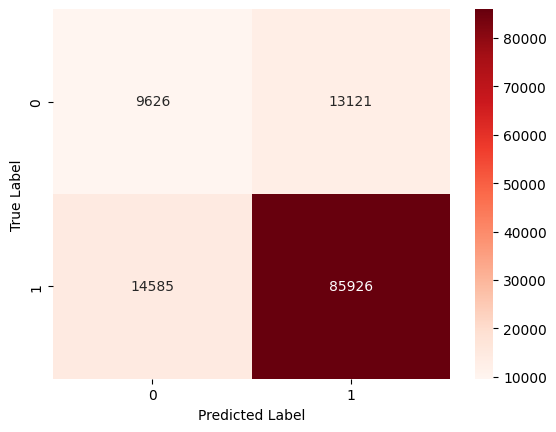

In [29]:
from sklearn.metrics import confusion_matrix

conf_matrix = confusion_matrix(y_test, y_pred_test)

sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Reds')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

In [94]:
X_train1, X_test1, y_train1, y_test1 = train_test_split(df_all, Y_1, random_state=42)
X_train1 = scaler.fit_transform(X_train1)
X_test1 = scaler.transform(X_test1)

print(X_train1.shape, y_train1.shape)

(374292, 138) (374292,)


In [121]:
class_weights1 = compute_sample_weight('balanced', y=y_train1)
for i in range(0, class_weights1.size):
    tmp = class_weights1[i]
    if int(tmp)==40:
        class_weights1[i] = 8.5
    else: class_weights1[i] = 0.8

print(np.unique(class_weights1))

[0.8 8.5]


In [32]:
# from imblearn.over_sampling import RandomOverSampler
# ros = RandomOverSampler()

# X_train1, y_train1 = ros.fit_resample(X_train1, y_train1)

In [ ]:
# from sklearn.ensemble import IsolationForest
# from sklearn.svm import OneClassSVM
# from sklearn.neighbors import LocalOutlierFactor
# from sklearn.neighbors import KNeighborsClassifier


# if_model = KNeighborsClassifier(n_neighbors=10, n_jobs=-1, weights='distance')
# # if_model = IsolationForest(n_estimators=50, bootstrap=True, warm_start=True, n_jobs=-1, random_state=42)
# # if_model = XGBClassifier(n_estimators = 100, eval_metric='merror', random_state=42)
# # if_model = LocalOutlierFactor(n_neighbors=20, n_jobs=-1)
# # if_model = OneClassSVM(degree=3)
# if_model.fit(X_train1, y_train1) # , sample_weight=class_weights1

# y_pred_train1 = if_model.predict(X_train1)
# y_pred_test1 = if_model.predict(X_test1)
# y_pred_train[y_pred_train == -1] = 0
# y_pred_test[y_pred_test == -1] = 0

# f1_train1 = f1_score(y_train1, y_pred_train1, average='macro')
# f1_test1 = f1_score(y_test1, y_pred_test1, average='macro')
# print(f1_train1, f1_test1)

In [122]:
if_model = XGBClassifier(n_estimators = 100, eval_metric='merror', random_state=42)
if_model.fit(X_train1, y_train1, sample_weight=class_weights1)

y_pred_train1 = if_model.predict(X_train1)
y_pred_test1 = if_model.predict(X_test1)

f1_train1 = f1_score(y_train1, y_pred_train1, average='macro')
f1_test1 = f1_score(y_test1, y_pred_test1, average='macro')
print(f1_train1, f1_test1)

0.6335297250566092 0.5719307983556986


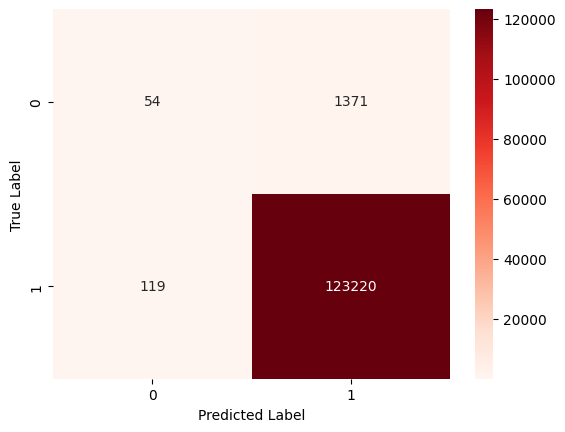

In [101]:
conf_matrix1 = confusion_matrix(y_test1, y_pred_test1)

sns.heatmap(conf_matrix1, annot=True, fmt='d', cmap='Reds')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

In [123]:
import random

X_train_all, X_test_all, y_train_all, y_test_all = train_test_split(df_all, Y_train, random_state=42)
X_train_all = scaler.fit_transform(X_train_all)
X_test_all = scaler.transform(X_test_all)

y1_train = model.predict(X_train_all)
y1_train = y1_train + 2
y2_train = if_model.predict(X_train_all)

y_all_train = [random.randint(0, 0) for i in range(X_train_all.shape[0])]
for i in range(X_train_all.shape[0]):
    if y2_train[i] == 0:
        y_all_train[i] = 1
    else: 
        y_all_train[i] = y1_train[i]
print(np.unique(y_all_train))

y1_test = model.predict(X_test_all)
y1_test = y1_test + 2
y2_test = if_model.predict(X_test_all)

y_all_test = [random.randint(0, 0) for i in range(X_test_all.shape[0])]
for i in range(X_test_all.shape[0]):
    if y2_test[i] == 0:
        y_all_test[i] = 1
    else: 
        y_all_test[i] = y1_test[i]
print(np.unique(y_all_test))
print(np.unique(y_train_all), np.unique(y_test_all))
    
f1_train_all = f1_score(y_train_all, y_all_train, average='macro')
f1_test_all = f1_score(y_test_all, y_all_test, average='macro')
print(f1_train_all, f1_test_all)

[1 2 3]
[1 2 3]
[1 2 3] [1 2 3]
0.4349798837990546 0.3955837808669644


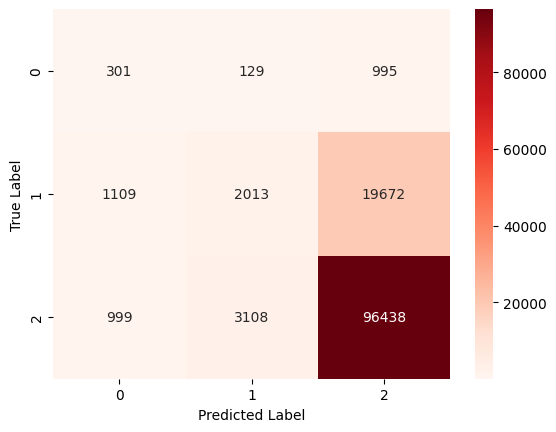

In [124]:
conf_matrix1 = confusion_matrix(y_test_all, y_all_test)

sns.heatmap(conf_matrix1, annot=True, fmt='d', cmap='Reds')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

In [138]:
X_testFinal = pd.read_csv('../data/X_test.csv', index_col=0)

X_testFinal = X_testFinal.reindex(df_all.columns, axis=1, fill_value=0)
X_testFinal_data = scaler.transform(X_testFinal)
X_testFinal.describe()

,generic_make_model_-1,generic_make_model_ABARTH,generic_make_model_AJS,generic_make_model_ALEXANDER,generic_make_model_ALFA,generic_make_model_APRILIA,generic_make_model_AUDI,generic_make_model_BENELLI,generic_make_model_BENTLEY,generic_make_model_BMW,...,police_force,first_road_class,road_type,speed_limit,junction_detail,junction_control,second_road_class,light_conditions,weather_conditions,road_surface_conditions
count,166352.0,166352.0,166352.0,166352.0,166352.0,166352.0,166352.0,166352.0,166352.0,166352.0,...,166352.000000,166352.000000,166352.000000,166352.000000,166352.000000,166352.000000,166352.000000,166352.000000,166352.000000,166352.000000
mean,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,28.323892,4.149598,5.238975,37.547730,3.767667,1.687151,3.008446,2.051848,1.634257,1.371369
std,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,24.336775,1.469986,1.665436,14.710353,11.917428,2.512841,2.759564,1.732798,1.787258,0.933177
min,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.000000,1.000000,1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000
25%,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,5.000000,3.000000,6.000000,30.000000,0.000000,-1.000000,0.000000,1.000000,1.000000,1.000000
50%,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,23.000000,4.000000,6.000000,30.000000,2.000000,2.000000,3.000000,1.000000,1.000000,1.000000
75%,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,45.000000,6.000000,6.000000,50.000000,3.000000,4.000000,6.000000,4.000000,1.000000,2.000000
max,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,99.000000,6.000000,9.000000,70.000000,99.000000,9.000000,6.000000,7.000000,9.000000,9.000000


In [139]:
y1_final = model.predict(X_testFinal_data)
y1_final = y1_final + 2
y2_final = if_model.predict(X_testFinal_data)

y_final = [random.randint(1, 3) for i in range(X_testFinal_data.shape[0])]
for i in range(X_testFinal_data.shape[0]):
    if y2_final[i] == 0:
        y_final[i] = 1
    else: 
        y_final[i] = y1_final[i]

In [140]:
print(np.unique(y_final), y_final)

[1 2 3] [3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 2, 3, 3, 3, 3, 3, 1, 3, 3, 2, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 2, 3, 3, 3, 3, 3, 3, 3, 2, 3, 1, 3, 3, 3, 3, 3, 3, 3, 2, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 2, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 1, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 1, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 2, 3, 3, 3, 3, 3, 2, 3, 3, 3, 3, 3, 1, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 1, 2, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 2, 3, 3, 3, 3, 3, 1, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 1, 3, 3, 3, 3, 3, 3, 3, 3, 2, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 2

In [141]:
my_file = open("../predicts/kernel_4.csv", "w+")

my_file.write("Id,casualty_severity\n")
my_i = 0
for i, row in X_testFinal.iterrows():
    my_file.write(f"{i}, {y_final[my_i]}\n")
    my_i = my_i+1
my_file.close()